### Exploring the receptor-ligand pairs from <https://m2or.chemsensim.fr/>.

In [19]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../scripts")
from plotting_functions import custom_plots

In [20]:
%config InlineBackend.figure_formats = ["svg"]
plt.rcParams.update(custom_plots())

FIGSIZE = (6, 4)

FIGDIR = Path("figures")
FIGDIR.mkdir(exist_ok=True)

def savefig(fig, name):
    fig.savefig(FIGDIR / f"{name}.svg", bbox_inches="tight")

In [21]:
df = pd.read_csv("m2or_pairs.csv", sep=";")
df

,Species,Gene Name,UniProt ID,Mutation,Sequence,Molecule Name,CID,CAS,InChIKey,SMILES,Mixture,Responsive,Data Quality,Number of Unique Value Screen
0,homo sapiens,OR10S1,Q8NGN2,NaN,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,(-)-limonene,439250.0,5989-54-8,XMGQYMWWDOXHJM-SNVBAGLBSA-N,CC1=CC[C@H](CC1)C(=C)C,mono,0,primaryScreening,1.0
1,homo sapiens,OR10S1,Q8NGN2,NaN,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,(+)-carvone,16724.0,6485-40-1,ULDHMXUKGWMISQ-VIFPVBQESA-N,CC1=CC[C@@H](CC1=O)C(=C)C,mono,0,secondaryScreening,2.0
2,homo sapiens,OR10S1,Q8NGN2,NaN,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,(+)-menthol,165675.0,2216-51-5,NOOLISFMXDJSKH-AEJSXWLSSA-N,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C,mono,0,primaryScreening,1.0
3,homo sapiens,OR10S1,Q8NGN2,NaN,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,1-butanol,263.0,71-36-3,LRHPLDYGYMQRHN-UHFFFAOYSA-N,CCCCO,mono,0,primaryScreening,1.0
4,homo sapiens,OR10S1,Q8NGN2,NaN,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,1-butoxy-2-propanol,21210.0,5131-66-8,RWNUSVWFHDHRCJ-UHFFFAOYSA-N,CCCCOCC(C)O,sum of isomers,0,primaryScreening,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53439,homo sapiens,OR51F1_OR51F1P,A6NGY5,NaN,MLQNQDTMEILSNSTSKFPTFLLTGIPGLESAHVWISIPFCCFYAI...,N-hexanal,6184.0,66-25-1,JARKCYVAAOWBJS-UHFFFAOYSA-N,CCCCCC=O,mono,0,primaryScreening,1.0
53440,homo sapiens,OR51T1,Q8NGJ9,NaN,MAIFNNTTSSSSNFLLTAFPGLECAHVWISIPVCCLYTIALLGNSM...,N-hexanal,6184.0,66-25-1,JARKCYVAAOWBJS-UHFFFAOYSA-N,CCCCCC=O,mono,0,primaryScreening,1.0
53441,homo sapiens,OR52E5,Q8NH55,NaN,MLHTNNTQFHPSTFLVVGVPGLEDVHVWIGFPFFAVYLTALLGNII...,N-hexanal,6184.0,66-25-1,JARKCYVAAOWBJS-UHFFFAOYSA-N,CCCCCC=O,mono,0,primaryScreening,1.0
53442,homo sapiens,OR52L1,Q8NGH7,NaN,MTLVSFFSFLSKPLIMLLSNSSWRLSQPSFLLVGIPGLEESQHWIA...,N-hexanal,6184.0,66-25-1,JARKCYVAAOWBJS-UHFFFAOYSA-N,CCCCCC=O,mono,0,primaryScreening,1.0


**Columns**

| column | content |
|---|---|
| `Species`, `Gene Name`, `UniProt ID` | the olfactory receptor tested |
| `Mutation`, `Sequence` | receptor variant / its amino-acid sequence |
| `Molecule Name`, `CID`, `CAS`, `InChIKey`, `SMILES` | the ligand (odorant) |
| `Mixture` | whether the stimulus is a single compound, sum-of-isomers, or a mixture |
| `Responsive` | **label**: 1 = receptor activated by the molecule, 0 = not |
| `Data Quality` | assay type: primary / secondary screening or dose-response (`ec50`) |
| `Number of Unique Value Screen` | # independent measurements aggregated into the row |

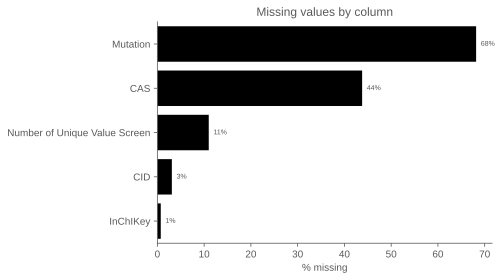

In [22]:
miss = (df.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.barplot(x=miss.values, y=miss.index, color="#000000", ax=ax)
ax.set_xlabel("% missing")
ax.set_ylabel("")
ax.set_title("Missing values by column")
for i, v in enumerate(miss.values):
    ax.text(v + 1, i, f"{v:.0f}%", va="center", fontsize=7)
savefig(fig, "01_missingness")
plt.show()

Responsive
0    50320
1     3124
Name: count, dtype: int64

Positive (hit) rate: 5.85%


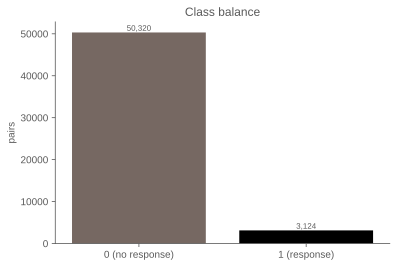

In [23]:
resp = df["Responsive"].value_counts().sort_index()
rate = df["Responsive"].mean()
print(resp)
print(f"\nPositive (hit) rate: {rate:.2%}")

fig, ax = plt.subplots(figsize=FIGSIZE)
labels = ["0 (no response)", "1 (response)"]
sns.barplot(x=labels, y=resp.values, hue=labels,
            palette=["#79665F", "#000000"], legend=False, ax=ax)
for i, v in enumerate(resp.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("pairs")
ax.set_title(f"Class balance")
savefig(fig, "02_class_balance")
plt.show()

Species
homo sapiens              42917
mus musculus              10243
pan troglodytes              58
pongo abelii                 51
bos taurus                   41
pan paniscus                 26
ovis aries                   25
canis lupus familiaris       25
puma concolor                25
vulpes vulpes                25
rattus norvegicus             3
dipodomys ordii               1
macaca mulatta                1
ursus maritimus               1
camelus ferus                 1
equus caballus                1
Name: count, dtype: int64


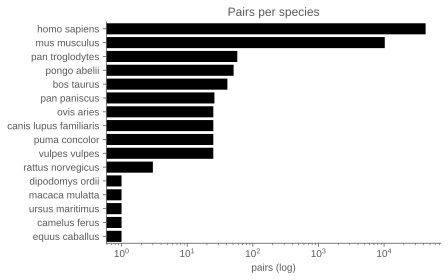

In [24]:
sp = df["Species"].value_counts()
print(sp)

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.barplot(x=sp.values, y=sp.index, color="#000000", ax=ax)
ax.set_xscale("log")
ax.set_xlabel("pairs (log)")
ax.set_ylabel("")
ax.set_title("Pairs per species")
savefig(fig, "03_species")
plt.show()

In [25]:
sp_stats = (df.groupby("Species")["Responsive"]
              .agg(n="count", hit_rate="mean")
              .query("n >= 50")
              .sort_values("n", ascending=False))
sp_stats["hit_rate"] = (sp_stats["hit_rate"] * 100).round(1)
sp_stats

,n,hit_rate
Species,,
homo sapiens,42917,5.4
mus musculus,10243,5.8
pan troglodytes,58,81.0
pongo abelii,51,51.0


In [26]:
print(f"Unique sequences   : {df['Sequence'].nunique()}")
print(f"  wild type        : {df[df['Mutation'].isna()]['Sequence'].nunique()}")
print(f"  mutant           : {df[df['Mutation'].notna()]['Sequence'].nunique()}")
print(f"Unique UniProt IDs : {df['UniProt ID'].nunique()}")
print(f"Unique gene names  : {df['Gene Name'].nunique()}")

per_receptor = df.groupby("Gene Name").agg(
    n_tests=("Responsive", "size"),
    n_hits=("Responsive", "sum"),
)
per_receptor["hit_rate"] = per_receptor["n_hits"] / per_receptor["n_tests"]

print("\nTests per receptor - distribution:")
print(per_receptor["n_tests"].describe().round(1))

Unique sequences   : 1402
  wild type        : 589
  mutant           : 813
Unique UniProt IDs : 598
Unique gene names  : 563

Tests per receptor - distribution:
count    563.0
mean      94.9
std       61.1
min        1.0
25%       63.0
50%       89.0
75%      109.5
max      564.0
Name: n_tests, dtype: float64


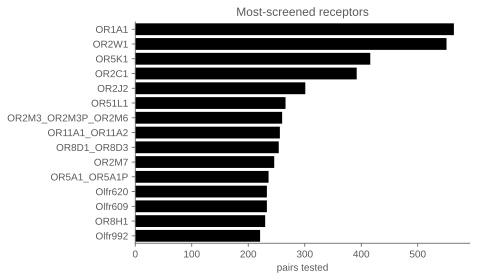

In [27]:
top_tested = per_receptor.sort_values("n_tests", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=top_tested["n_tests"], y=top_tested.index, color="#000000", ax=ax)
ax.set_xlabel("pairs tested")
ax.set_ylabel("")
ax.set_title("Most-screened receptors")
savefig(fig, "04_top_receptors")
plt.show()

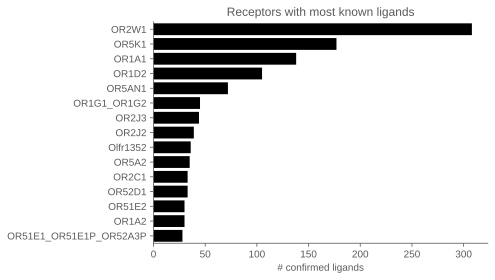

In [28]:
top_hits = (per_receptor[per_receptor["n_hits"] > 0]
            .sort_values("n_hits", ascending=False).head(15))
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=top_hits["n_hits"], y=top_hits.index, color="#000000", ax=ax)
ax.set_xlabel("# confirmed ligands")
ax.set_ylabel("")
ax.set_title("Receptors with most known ligands")
savefig(fig, "05_top_receptor_hits")
plt.show()

Unique SMILES        : 771
Unique molecule names: 1223


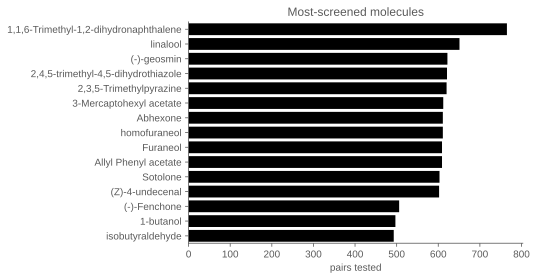

In [29]:
n_smiles = df["SMILES"].nunique()
n_names = df["Molecule Name"].nunique()
print(f"Unique SMILES        : {n_smiles}")
print(f"Unique molecule names: {n_names}")

per_mol = df.groupby("Molecule Name").agg(
    n_tests=("Responsive", "size"),
    n_hits=("Responsive", "sum"),
)
top_mol = per_mol.sort_values("n_tests", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=top_mol["n_tests"], y=top_mol.index, color="#000000", ax=ax)
ax.set_xlabel("pairs tested")
ax.set_ylabel("")
ax.set_title("Most-screened molecules")
savefig(fig, "06_top_molecules")
plt.show()

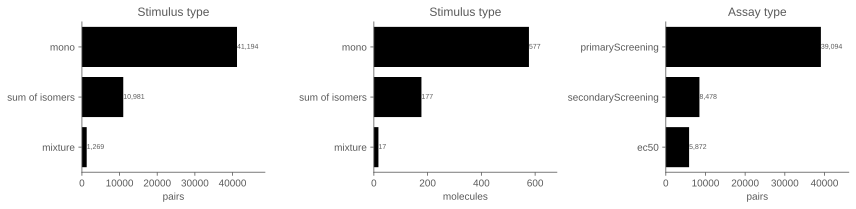

                        n  hit_rate
Data Quality                       
ec50                 5872  0.249319
primaryScreening    39094  0.034762
secondaryScreening   8478  0.035504


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

mix_pairs = df["Mixture"].value_counts()
mix_mols = df.groupby("Mixture")["SMILES"].nunique().reindex(mix_pairs.index)
qual = df["Data Quality"].value_counts()

for ax, vc, title, xlabel in [
    (axes[0], mix_pairs, "Stimulus type", "pairs"),
    (axes[1], mix_mols, "Stimulus type", "molecules"),
    (axes[2], qual, "Assay type", "pairs"),
]:
    sns.barplot(x=vc.values, y=vc.index, ax=ax, color="#000000")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.margins(x=0.18)
    for i, v in enumerate(vc.values):
        ax.text(v, i, f" {v:,}", va="center", fontsize=7)

fig.tight_layout()
savefig(fig, "07_assay_metadata")
plt.show()

print(df.groupby("Data Quality")["Responsive"].agg(n="count", hit_rate="mean"))

In [31]:
df["is_mutant"] = df["Mutation"].notna()
mut = df["is_mutant"].value_counts()
print("Wild-type vs mutant rows:")
print(mut.rename({False: "wild-type", True: "mutant"}))
print("\nHit rate:")
print(df.groupby("is_mutant")["Responsive"].mean().rename(
    {False: "wild-type", True: "mutant"}))

Wild-type vs mutant rows:
is_mutant
wild-type    36432
mutant       17012
Name: count, dtype: int64

Hit rate:
is_mutant
wild-type    0.051768
mutant       0.072772
Name: Responsive, dtype: float64


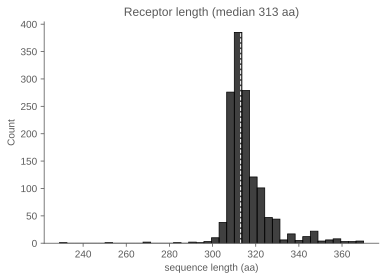

count    1402.0
mean      316.2
std        10.7
min       229.0
25%       311.0
50%       313.0
75%       319.0
max       370.0
Name: Sequence, dtype: float64


In [32]:
seq_len = df.drop_duplicates("Sequence")["Sequence"].str.len()

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.histplot(seq_len, bins=40, color="#000000", ax=ax)
ax.axvline(seq_len.median(), color="w", ls="--", lw=1)
ax.set_xlabel("sequence length (aa)")
ax.set_title(f"Receptor length (median {seq_len.median():.0f} aa)")
savefig(fig, "08_seq_length")
plt.show()
print(seq_len.describe().round(1))

In [33]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen

mols = (df.dropna(subset=["SMILES"])
        .drop_duplicates("SMILES")[["Molecule Name", "SMILES"]]
        .copy())

def descriptors(smi):
    m = Chem.MolFromSmiles(smi)
    if m is None:
        return pd.Series({"MW": np.nan, "LogP": np.nan, "HBD": np.nan,
                          "HBA": np.nan, "n_heavy": np.nan})
    return pd.Series({
        "MW": Descriptors.MolWt(m),
        "LogP": Crippen.MolLogP(m),
        "HBD": Descriptors.NumHDonors(m),
        "HBA": Descriptors.NumHAcceptors(m),
        "n_heavy": m.GetNumHeavyAtoms(),
    })

desc = mols.join(mols["SMILES"].apply(descriptors))
n_bad = desc["MW"].isna().sum()
print(f"Unique molecules: {len(desc)}  |  unparseable SMILES: {n_bad}")
desc.dropna().describe().round(2)

Unique molecules: 771  |  unparseable SMILES: 0


,MW,LogP,HBD,HBA,n_heavy
count,771.00,771.00,771.00,771.00,771.00
mean,162.08,2.32,0.51,1.67,11.37
std,61.73,1.41,0.93,1.15,4.49
min,44.05,-5.55,0.00,0.00,2.00
25%,128.69,1.51,0.00,1.00,9.00
50%,152.24,2.32,0.00,1.00,11.00
75%,186.30,3.07,1.00,2.00,13.00
max,1060.23,6.81,12.00,13.00,76.00


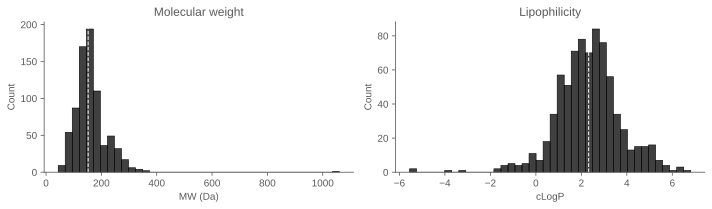

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
sns.histplot(desc["MW"].dropna(), bins=40, color="#000000", ax=axes[0])
axes[0].axvline(desc["MW"].median(), color="w", ls="--", lw=1)
axes[0].set_title("Molecular weight")
axes[0].set_xlabel("MW (Da)")
sns.histplot(desc["LogP"].dropna(), bins=40, color="#000000", ax=axes[1])
axes[1].axvline(desc["LogP"].median(), color="w", ls="--", lw=1)
axes[1].set_title("Lipophilicity")
axes[1].set_xlabel("cLogP")
fig.tight_layout()
savefig(fig, "09_chemspace")
plt.show()

Matrix sparsity: How much of the receptor × molecule matrix has actually been tested.

In [35]:
R = df["Gene Name"].nunique()
M = df["SMILES"].nunique()
tested = df.drop_duplicates(["Gene Name", "SMILES"]).shape[0]
possible = R * M
print(f"receptors           : {R:,}")
print(f"molecules           : {M:,}")
print(f"possible pairs      : {possible:,}")
print(f"distinct pairs tested: {tested:,}")
print(f"matrix filled       : {tested / possible:.2%}")

receptors           : 563
molecules           : 771
possible pairs      : 434,073
distinct pairs tested: 45,530
matrix filled       : 10.49%


## Summary

- **53,444 pairs** over **1,402 unique receptor sequences** (589 wild type, 813 mutant) and
  **771 molecules** in **16 species**, dominated by human and mouse. The 1,402 sequences sit
  under only 598 UniProt accessions, because a wild type shares its accession with its mutants.
- **Heavily imbalanced** - ~6% positives. Use stratified splits, class weights, PR-AUC.
- **Coverage is uneven:** a few receptors and a few reference odorants account for a large
  share of the experiments.
- **Mostly wild type**, with a mutant minority; `ec50` rows are the highest-confidence subset.
- **Ligands are small and lipophilic** (mostly < 300 Da, positive LogP); receptors are
  ~314 aa 7-TM GPCRs.
- The **receptor x molecule matrix is ~10% filled**.

Counts here are for the raw export. Dropping mixtures leaves 52,175 rows over 1,399 sequences
and 754 odorants - the modelling table built in
[`Model_Inputs/Data_Preparation/`](../Model_Inputs/Data_Preparation/).